In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"

In [32]:
sv_values = set()
for i in range(0, 15):
    for j in range(0, 9):
        for k in range(0, 6):
            for l in range(0, 5):
                for n in range(0, 4):
                    for m in range(0, 4):
                            v = 2**i * 3**j * 5**k * 7**l * 11**n * 13**m
                            if v > 1000 and v <= 16384:
                                sv_values.add(v)
sv = sorted(sv_values)

In [33]:
max(sv)

16384

In [34]:
warmup_iter = 2

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_3",
]

plan_data_sv = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {}
}

plan_data_bad = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {}
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_type = data["plan_type"]
        time = np.average(data["timings"][warmup_iter:])
        plan_size = data["plan_size"]
        if plan_size in sv_values:
            plan_data_sv[plan_type][plan_size] = time
        else:
            plan_data_bad[plan_type][plan_size] = time
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [35]:
plot_data_sv = {}
for plan_type in plan_data_sv.keys():
    name = plan_type
    plan_sizes = sorted(plan_data_sv[plan_type].keys())
    times = [plan_data_sv[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data_sv[name] = {}
    plot_data_sv[name]["plan_sizes"] = plan_sizes
    plot_data_sv[name]["times"] = times

plot_data_bad = {}
for plan_type in plan_data_bad.keys():
    name = plan_type
    plan_sizes = sorted(plan_data_bad[plan_type].keys())
    times = [plan_data_bad[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data_bad[name] = {}
    plot_data_bad[name]["plan_sizes"] = plan_sizes
    plot_data_bad[name]["times"] = times

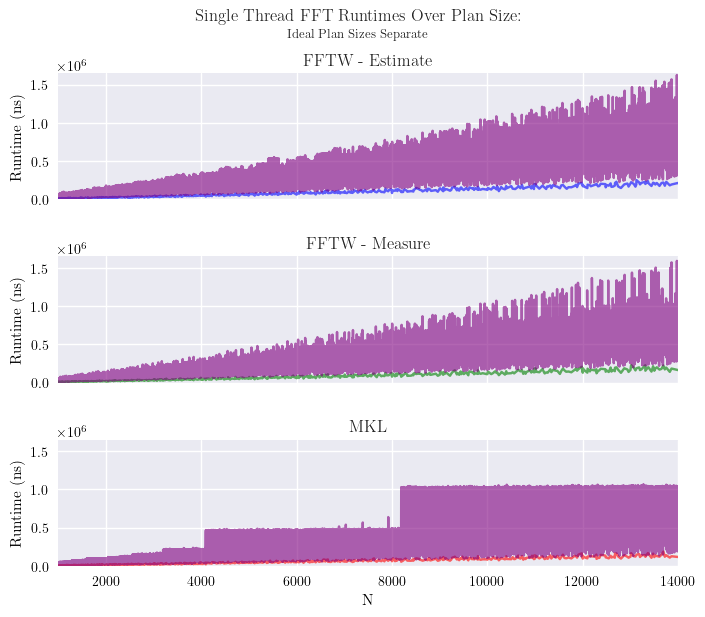

In [36]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])
        
xlow = 1000
xhi = 14000
ylow = 0
yhi = 1650000
plan_type = "Estimate"
ax_1.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="blue",
    alpha = 0.6
)
ax_1.plot(
    plot_data_bad[plan_type]["plan_sizes"], 
    plot_data_bad[plan_type]["times"], 
    color="purple",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_ylim(ylow, yhi)
ax_1.set_xlim(xlow, xhi)

plan_type = "Measure"
ax_2.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="green",
    alpha = 0.6
)
ax_2.plot(
    plot_data_bad[plan_type]["plan_sizes"], 
    plot_data_bad[plan_type]["times"], 
    color="purple",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_ylim(ylow, yhi)
ax_2.set_xlim(xlow, xhi)

plan_type = "MKL_OUT_OF_PLACE"
ax_3.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="red",
    alpha = 0.6
)
ax_3.plot(
    plot_data_bad[plan_type]["plan_sizes"], 
    plot_data_bad[plan_type]["times"], 
    color="purple",
    alpha = 0.6
)
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_xlabel("N")
ax_3.set_title("MKL")
ax_3.set_ylim(ylow, yhi)
ax_3.set_xlim(xlow, xhi)


fig.suptitle("Single Thread FFT Runtimes Over Plan Size:\n{\small Ideal Plan Sizes Separate}")
plt.savefig(f"{output_dir}/plan_type_runtimes_exp3.pdf")

In [63]:
sv_plan_sizes = []
sv_speedup = []
for plan_size in sorted(plan_data_sv["Estimate"].keys()):
    sv_plan_sizes.append(plan_size)
    est_time = plan_data_sv["Estimate"][plan_size]
    mes_time = plan_data_sv["Measure"][plan_size]
    sv_speedup.append(est_time / mes_time)

mkl_plan_sizes = []
mkl_speedup = []
for plan_size in sorted(plan_data_sv["Measure"].keys()):
    mkl_plan_sizes.append(plan_size)
    mes_time = plan_data_sv["Measure"][plan_size]
    mkl_time = plan_data_sv["MKL_OUT_OF_PLACE"][plan_size]
    mkl_speedup.append(mes_time / mkl_time)


mklest_plan_sizes = []
mklest_speedup = []
for plan_size in sorted(plan_data_sv["Estimate"].keys()):
    mklest_plan_sizes.append(plan_size)
    mes_time = plan_data_sv["Estimate"][plan_size]
    mkl_time = plan_data_sv["MKL_OUT_OF_PLACE"][plan_size]
    mklest_speedup.append(mes_time / mkl_time)

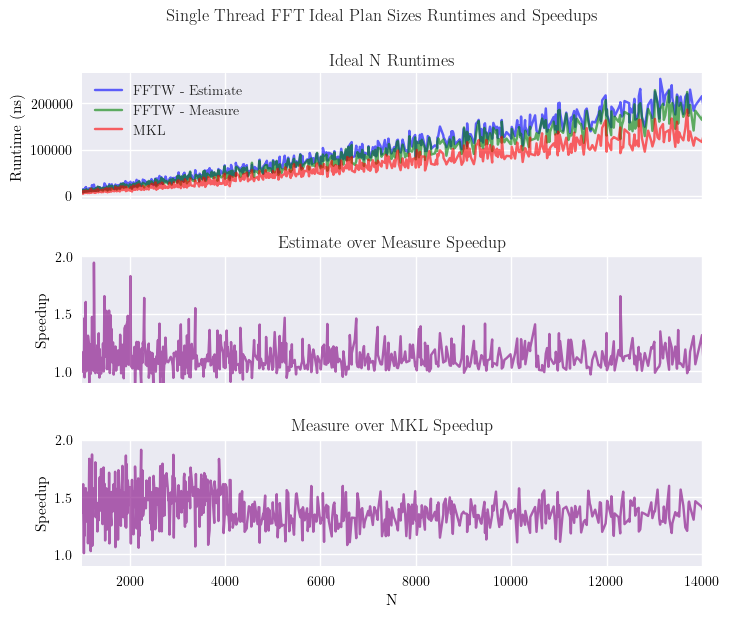

In [66]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])
        
xlow = 1000
xhi = 14000

plan_type = "Estimate"
ax_1.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="blue",
    label="FFTW - Estimate",
    alpha = 0.6
)
plan_type = "Measure"
ax_1.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="green",
    label="FFTW - Measure",
    alpha = 0.6
)
plan_type = "MKL_OUT_OF_PLACE"
ax_1.plot(
    plot_data_sv[plan_type]["plan_sizes"], 
    plot_data_sv[plan_type]["times"], 
    color="red",
    label="MKL",
    alpha = 0.6
)
ax_1.legend()
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("Ideal N Runtimes")
#ax_1.set_ylim(ylow, yhi)
ax_1.set_xlim(xlow, xhi)

s_ylo = 0.9
s_yhi = 2.0

ax_2.plot(
    sv_plan_sizes, 
    sv_speedup, 
    color="purple",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Speedup")
ax_2.set_title("Estimate over Measure Speedup")
ax_2.set_ylim(s_ylo, s_yhi)
ax_2.set_xlim(xlow, xhi)

ax_3.plot(
    mkl_plan_sizes, 
    mkl_speedup, 
    color="purple",
    alpha = 0.6
)
ax_3.set_ylabel("Speedup")
ax_3.set_xlabel("N")
ax_3.set_title("Measure over MKL Speedup")
ax_3.set_ylim(s_ylo, s_yhi)
ax_3.set_xlim(xlow, xhi)


fig.suptitle("Single Thread FFT Ideal Plan Sizes Runtimes and Speedups")
plt.savefig(f"{output_dir}/ideal_runtimes_speedup.pdf")

In [67]:
# Measure speedup,
# For each plansize in measure
# find next largest 

nextest_plan_sizes = []
nextest_speedup = []

def find_next_sv_est(plan_size):
    i = plan_size
    while i < 14050:
        if i in sv_values:
             return plan_data_sv["Estimate"][i]
        i += 1

for plan_size in sorted(plan_data_bad["Estimate"].keys()):
    nextest_plan_sizes.append(plan_size)
    mes_time = plan_data_bad["Estimate"][plan_size]
    next_time = find_next_sv_est(plan_size)
    nextest_speedup.append(mes_time / next_time)

next_plan_sizes = []
next_speedup = []

def find_next_sv(plan_size):
    i = plan_size
    while i < 14050:
        if i in sv_values:
             return plan_data_sv["Measure"][i]
        i += 1

for plan_size in sorted(plan_data_bad["Measure"].keys()):
    next_plan_sizes.append(plan_size)
    mes_time = plan_data_bad["Measure"][plan_size]
    next_time = find_next_sv(plan_size)
    next_speedup.append(mes_time / next_time)

nextmkl_plan_sizes = []
nextmkl_speedup = []

def find_next_sv_mkl(plan_size):
    i = plan_size
    while i < 14050:
        if i in sv_values:
             return plan_data_sv["MKL_OUT_OF_PLACE"][i]
        i += 1

for plan_size in sorted(plan_data_bad["MKL_OUT_OF_PLACE"].keys()):
    nextmkl_plan_sizes.append(plan_size)
    mes_time = plan_data_bad["MKL_OUT_OF_PLACE"][plan_size]
    next_time = find_next_sv_mkl(plan_size)
    nextmkl_speedup.append(mes_time / next_time)

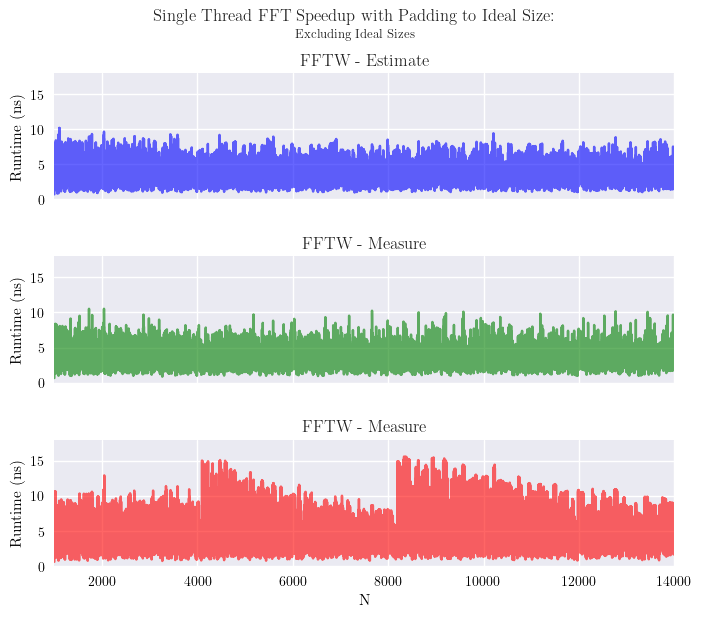

In [68]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

xlow = 1000
xhi = 14000
ylo = 0.0
yhi = 18

ax_1.plot(
    nextest_plan_sizes, 
    nextest_speedup, 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_xlim(xlow, xhi)
ax_1.set_ylim(ylo, yhi)

ax_2.plot(
    next_plan_sizes, 
    next_speedup, 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_xlim(xlow, xhi)
ax_2.set_ylim(ylo, yhi)

plan_type = "Measure"

ax_3.plot(
    nextmkl_plan_sizes, 
    nextmkl_speedup, 
    color="red",
    alpha = 0.6
)
ax_3.set_xlabel("N")
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_title("FFTW - Measure")
ax_3.set_xlim(xlow, xhi)
ax_3.set_ylim(ylo, yhi)


fig.suptitle("Single Thread FFT Speedup with Padding to Ideal Size:\n{\small Excluding Ideal Sizes}")
plt.savefig(f"{output_dir}/padding_speedup.pdf")

In [69]:
nextest_plan_sizes_2 = []
nextest_speedup_2 = []

powers = set([1024, 2048, 4096, 8192, 16384])

def find_next_sv_est_2(plan_size):
    i = plan_size
    while i <= 16384:
        if i in powers:
             return plan_data_sv["Estimate"][i]
        i += 1

for plan_size in sorted(plan_data_bad["Estimate"].keys()):
    nextest_plan_sizes_2.append(plan_size)
    mes_time = plan_data_bad["Estimate"][plan_size]
    next_time = find_next_sv_est_2(plan_size)
    nextest_speedup_2.append(mes_time / next_time)

next_plan_sizes_2 = []
next_speedup_2 = []

def find_next_sv_2(plan_size):
    i = plan_size
    while i <= 16384:
        if i in powers:
             return plan_data_sv["Measure"][i]
        i += 1

for plan_size in sorted(plan_data_bad["Measure"].keys()):
    next_plan_sizes_2.append(plan_size)
    mes_time = plan_data_bad["Measure"][plan_size]
    next_time = find_next_sv_2(plan_size)
    next_speedup_2.append(mes_time / next_time)

nextmkl_plan_sizes_2 = []
nextmkl_speedup_2 = []

def find_next_sv_mkl_2(plan_size):
    i = plan_size
    while i <= 16384:
        if i in powers:
             return plan_data_sv["MKL_OUT_OF_PLACE"][i]
        i += 1

for plan_size in sorted(plan_data_bad["MKL_OUT_OF_PLACE"].keys()):
    nextmkl_plan_sizes_2.append(plan_size)
    mes_time = plan_data_bad["MKL_OUT_OF_PLACE"][plan_size]
    next_time = find_next_sv_mkl_2(plan_size)
    nextmkl_speedup_2.append(mes_time / next_time)

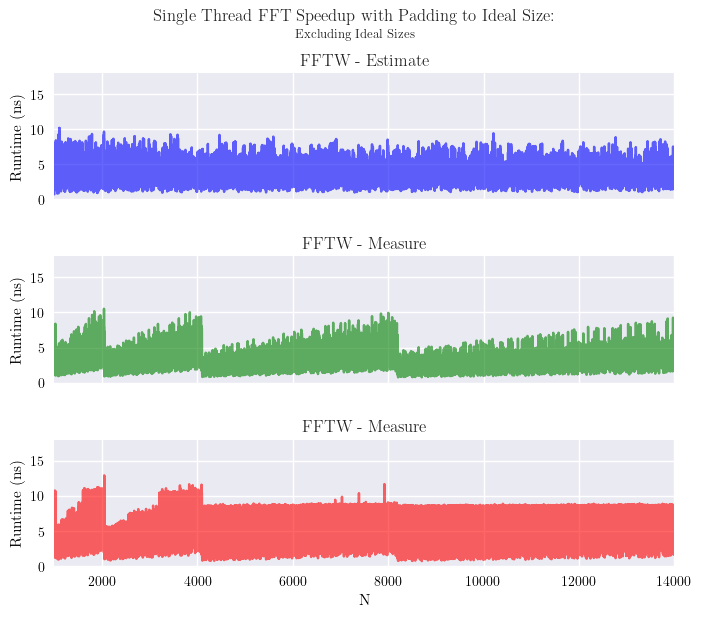

In [70]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

xlow = 1000
xhi = 14000
ylo = 0.0
yhi = 18

ax_1.plot(
    nextest_plan_sizes, 
    nextest_speedup, 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_xlim(xlow, xhi)
ax_1.set_ylim(ylo, yhi)

ax_2.plot(
    next_plan_sizes_2, 
    next_speedup_2, 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_xlim(xlow, xhi)
ax_2.set_ylim(ylo, yhi)

plan_type = "Measure"

ax_3.plot(
    nextmkl_plan_sizes_2, 
    nextmkl_speedup_2, 
    color="red",
    alpha = 0.6
)
ax_3.set_xlabel("N")
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_title("FFTW - Measure")
ax_3.set_xlim(xlow, xhi)
ax_3.set_ylim(ylo, yhi)


fig.suptitle("Single Thread FFT Speedup with Padding to Ideal Size:\n{\small Excluding Ideal Sizes}")
plt.savefig(f"{output_dir}/padding_speedup_2.pdf")

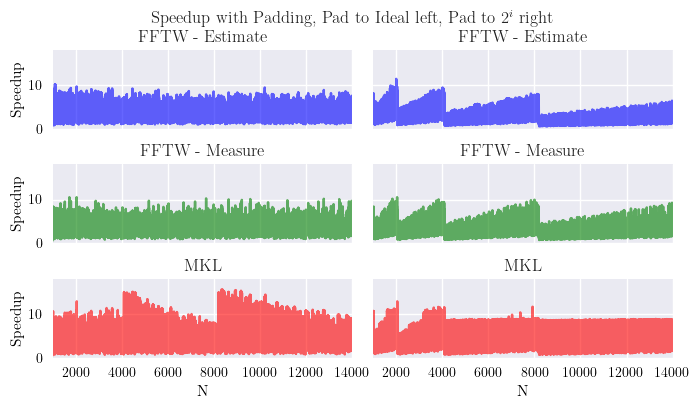

In [71]:
width = 8
height_ratio = 0.5
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 2
width_ratios = [1.0, 1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.07,
    hspace = 0.45,
)

ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

ax_4 = fig.add_subplot(gs1[0, 1])
ax_5 = fig.add_subplot(gs1[1, 1])
ax_6 = fig.add_subplot(gs1[2, 1])

xlow = 1000
xhi = 14000
ylo = 0.0
yhi = 18

ax_1.plot(
    nextest_plan_sizes, 
    nextest_speedup, 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Speedup")
ax_1.set_title("FFTW - Estimate")
ax_1.set_xlim(xlow, xhi)
ax_1.set_ylim(ylo, yhi)

ax_2.plot(
    next_plan_sizes, 
    next_speedup, 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Speedup")
ax_2.set_title("FFTW - Measure")
ax_2.set_xlim(xlow, xhi)
ax_2.set_ylim(ylo, yhi)

plan_type = "Measure"

ax_3.plot(
    nextmkl_plan_sizes, 
    nextmkl_speedup, 
    color="red",
    alpha = 0.6
)
ax_3.set_xlabel("N")
ax_3.set_ylabel("Speedup")
ax_3.set_title("MKL")
ax_3.set_xlim(xlow, xhi)
ax_3.set_ylim(ylo, yhi)

ax_4.plot(
    nextest_plan_sizes_2, 
    nextest_speedup_2, 
    color="blue",
    alpha = 0.6
)
ax_4.set_xticklabels([])
ax_4.set_yticklabels([])
#ax_4.set_ylabel("Runtime (ns)")
ax_4.set_title("FFTW - Estimate")
ax_4.set_xlim(xlow, xhi)
ax_4.set_ylim(ylo, yhi)

ax_5.plot(
    next_plan_sizes_2, 
    next_speedup_2, 
    color="green",
    alpha = 0.6
)
ax_5.set_xticklabels([])
ax_5.set_yticklabels([])
#ax_5.set_ylabel("Runtime (ns)")
ax_5.set_title("FFTW - Measure")
ax_5.set_xlim(xlow, xhi)
ax_5.set_ylim(ylo, yhi)

plan_type = "Measure"

ax_6.plot(
    nextmkl_plan_sizes_2, 
    nextmkl_speedup_2, 
    color="red",
    alpha = 0.6
)
ax_6.set_xlabel("N")
ax_6.set_yticklabels([])
#ax_6.set_ylabel("Runtime (ns)")
ax_6.set_title("MKL")
ax_6.set_xlim(xlow, xhi)
ax_6.set_ylim(ylo, yhi)


fig.suptitle("Speedup with Padding, Pad to Ideal left, Pad to $2^i$ right")
plt.savefig(f"{output_dir}/padding_speedup.pdf")